<a href="https://colab.research.google.com/github/sowjanyakaranam/heuristic-product-retrieval/blob/m2/heuristic_product_retrieval/notebooks/m2_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2 Experiments: Heuristic Product Retrieval

Colab-ready starter notebook for **CS 57200 – Heuristic Problem Solving (Track B)**.

This notebook demonstrates:
- correct baseline A*
- enhancement 1 (tight heuristic)
- brute-force correctness checks on tiny instances
- baseline vs enhancement experiments
- scaling plots


## 1. Setup

If you opened this notebook directly from GitHub, it is usually **read-only** in Colab.
Click **Copy to Drive** at the top first if you want to edit it.

If the repo is not already present in `/content`, clone it manually in the next cell.


In [ ]:
# Uncomment this if the repo is not already cloned in Colab
# !git clone https://github.com/sowjanyakaranam/heuristic-product-retrieval.git


In [4]:
import os
import sys

ROOT = "/content/heuristic-product-retrieval"

if os.path.exists(ROOT):
    os.chdir(ROOT)

sys.path.append(os.path.join(os.getcwd(), "src"))

print("Working directory:", os.getcwd())
print("Repo exists:", os.path.exists(ROOT))
print("Top-level files:", os.listdir(os.getcwd())[:10])


Working directory: /content/heuristic-product-retrieval
Repo exists: True
Top-level files: ['heuristic_product_retrieval', '.git']


In [5]:
# Clone repo (safe even if already exists)
!git clone https://github.com/sowjanyakaranam/heuristic-product-retrieval.git

# Move into repo
%cd heuristic-product-retrieval

# Install dependencies
!pip install -r requirements.txt

# Add src to path
import sys, os
sys.path.append(os.path.join(os.getcwd(), "src"))

print("Setup complete. Current dir:", os.getcwd())


Cloning into 'heuristic-product-retrieval'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 21 (delta 2), reused 7 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 9.42 KiB | 9.42 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/heuristic-product-retrieval/heuristic-product-retrieval
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Setup complete. Current dir: /content/heuristic-product-retrieval/heuristic-product-retrieval


In [25]:
%cd heuristic_product_retrieval
!ls

/content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval
data  notebooks  README.md  requirements.txt  src


In [26]:
!pip install -r requirements.txt

In [27]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "src"))
print("Current dir:", os.getcwd())
print("Src added:", os.path.join(os.getcwd(), "src"))

Current dir: /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval
Src added: /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval/src


In [48]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

print("Created results folders:")
print(os.listdir("results"))

Created results folders:
['tables', 'figures']


## 2. Imports


In [29]:
from data_utils import load_products_csv, filter_by_category
from experiments import run_correctness_test, run_baseline_vs_tight, run_scaling_experiment
from viz import plot_algorithm_comparison, plot_scaling
import pandas as pd


## 3. Load Sample Data


In [30]:
products = load_products_csv("data/sample_products.csv")
snacks = filter_by_category(products, "Snacks")
query_embedding = (0.22, 0.32, 0.44, 0.25)

print("Total products:", len(products))
print("Snack products:", len(snacks))
snacks[0]


Total products: 60
Snack products: 12


Product(pid='P001', title='Snacks Product 1', category='Snacks', price=29.11, embedding=(0.1718, 0.1441, 0.4741, 0.1316))

## 4. Correctness Tests

These compare A* with brute force on small instances.


In [31]:
r1 = run_correctness_test(snacks[:8], query_embedding, k=3, lam=0.30)
r2 = run_correctness_test(snacks[:10], query_embedding, k=4, lam=0.30)

bev = filter_by_category(products, "Beverages")[:8]
q_bev = (0.45, 0.34, 0.61, 0.29)
r3 = run_correctness_test(bev, q_bev, k=3, lam=0.30)

df_correctness = pd.DataFrame([r1, r2, r3])
df_correctness


,k,astar_objective,bruteforce_objective,objective_match,astar_nodes,astar_runtime_sec,bruteforce_runtime_sec
0,3,2.029266,2.029266,True,66,0.008075,0.000860
1,4,2.113888,2.113888,True,822,0.241481,0.003299
2,3,2.093944,2.093944,True,66,0.005609,0.000560


## 5. Experiment 1: Baseline vs Tight Heuristic


In [32]:
exp1 = [run_baseline_vs_tight(snacks[:12], query_embedding, k=k, lam=0.30) for k in [3, 4, 5]]
df_exp1 = pd.DataFrame(exp1)
df_exp1


,k,baseline_objective,tight_objective,baseline_nodes,tight_nodes,baseline_runtime_sec,tight_runtime_sec
0,3,2.039409,2.039409,146,146,0.026185,0.023283
1,4,2.123202,2.123202,1466,1466,0.409059,0.284344
2,5,1.905211,1.905211,13346,13346,4.796449,3.569797


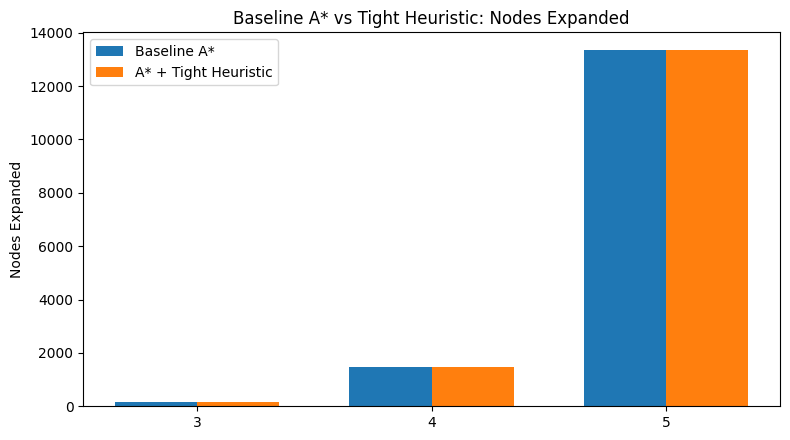

In [37]:
import os

os.makedirs("results/figures", exist_ok=True)
plot_algorithm_comparison(
    labels=[str(x) for x in df_exp1["k"]],
    baseline_vals=df_exp1["baseline_nodes"].tolist(),
    tight_vals=df_exp1["tight_nodes"].tolist(),
    ylabel="Nodes Expanded",
    title="Baseline A* vs Tight Heuristic: Nodes Expanded",
    output_path="results/figures/baseline_vs_tight_nodes.png",
)

## 6. Experiment 2: Scaling Study


In [38]:
pool = products[:40]
scaling = run_scaling_experiment(pool, query_embedding, sizes=[10, 15, 20, 25], k=4, lam=0.30)
df_scaling = pd.DataFrame(scaling)
df_scaling


,n,k,baseline_nodes,tight_nodes,baseline_runtime_sec,tight_runtime_sec
0,10,4,822,822,0.126827,0.145724
1,15,4,2957,2957,1.199294,1.051260
2,20,4,7242,7242,4.144488,3.583522
3,25,4,14427,14427,9.256994,9.466533


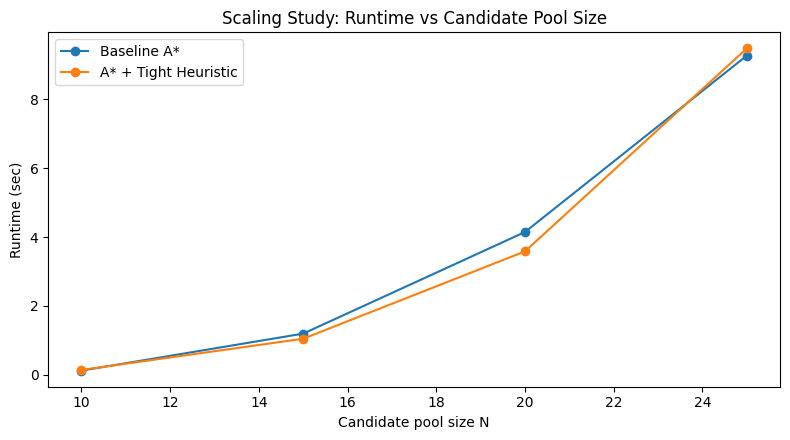

In [43]:
plot_scaling(
    ns=df_scaling["n"].tolist(),
    baseline_vals=df_scaling["baseline_runtime_sec"].tolist(),
    tight_vals=df_scaling["tight_runtime_sec"].tolist(),
    ylabel="Runtime (sec)",
    title="Scaling Study: Runtime vs Candidate Pool Size",
    output_path="results/figures/scaling_runtime.png",
)


## 7. Save Tables for the Report


In [50]:
df_correctness.to_csv("results/tables/correctness_tests.csv", index=False)
df_exp1.to_csv("results/tables/exp1_baseline_vs_tight.csv", index=False)
df_scaling.to_csv("results/tables/exp2_scaling.csv", index=False)
print("Saved tables and figures under results/.")


Saved tables and figures under results/.


In [49]:
df_correctness.to_csv("results/tables/correctness_tests.csv", index=False)
df_exp1.to_csv("results/tables/exp1_baseline_vs_tight.csv", index=False)
df_scaling.to_csv("results/tables/exp2_scaling.csv", index=False)

print("Tables saved.")

Tables saved.


## 8. Next Steps

- Replace `data/sample_products.csv` with cleaned real category data
- Replace synthetic embeddings with Sentence-BERT embeddings
- Add a third experiment varying `K` or `lambda`
- Save results and use them directly in M2 report
